<a href="https://colab.research.google.com/github/AshutoshJaiswal11/Financial_Analysis/blob/main/Financial_Analysis_04072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center>Analysis of Financial Statements: XYZ Bank<center>


In [1]:

# Import the necessary libraries

import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import cufflinks as cf
import numpy as np


import missingno
import datetime as dt

import warnings
warnings.filterwarnings('ignore')
import plotly.express
import time

from google.colab import files

In [ ]:
os.getcwd()

'/content'

In [2]:

# @title
uploaded = files.upload()  # Opens a file picker dialog

filename = next(iter(uploaded))



Saving Financial_Template_2026_1.xlsx to Financial_Template_2026_1.xlsx


In [3]:
# @title
df1 = pd.read_excel(f'{filename}',sheet_name = "BS", index_col=0, parse_dates=True)

In [4]:
df1

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Capital,14.5700,14.840000,15.64000,15.8300,15.220000,15.3800,16.1300,18.35000,20.15000,21.4300,23.3900,24.7400,24.4100,23.9400
Reserve Fund,88.2000,92.570000,95.94000,100.2500,104.740000,111.2200,118.1300,128.60000,139.95000,202.1300,216.4600,222.1700,262.2500,263.7600
Other Reserve,0.0000,0.000000,0.00000,0.0000,0.000000,0.0000,0.0000,0.00000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000
Deposits,565.1500,642.560000,746.98000,872.8800,1039.180000,1142.6100,1355.4300,1366.59000,1498.51000,1663.2600,1967.7200,2071.3800,2206.1300,2530.6600
Deposits- Demand,237.3630,218.470400,209.15440,235.6776,342.929400,354.2091,569.2806,464.64060,569.43380,415.8150,826.4424,745.6968,661.8390,1088.1838
Deposits- Term,327.7870,424.089600,537.82560,637.2024,696.250600,788.4009,786.1494,901.94940,929.07620,1247.4450,1141.2776,1325.6832,1544.2910,1442.4762
Borrowings,61.2300,119.662500,69.51250,26.8450,1.947500,1.3000,11.0800,12.06500,14.26500,14.0300,17.9900,15.6200,12.1100,11.2300
Borrowings- Interbank,9.7968,13.162875,12.51225,5.9059,0.447925,0.1560,1.8836,2.53365,2.99565,3.2269,2.8784,3.9050,2.7853,1.4599
Borrowings- Repo,51.4332,106.499625,57.00025,20.9391,1.499575,1.1440,9.1964,9.53135,11.26935,10.8031,15.1116,11.7150,9.3247,9.7701


In [6]:
# @title
df2=pd.DataFrame(df1)
print(f'Latest available Financial Year data: {str(df2.columns[-1].date())}')

# Extracting FY as column names

df2.columns = [df2.columns[i].date() for i in range(len(df2.columns))]

Latest available Financial Year data: 2026-03-31


In [7]:
df2

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Capital,14.5700,14.840000,15.64000,15.8300,15.220000,15.3800,16.1300,18.35000,20.15000,21.4300,23.3900,24.7400,24.4100,23.9400
Reserve Fund,88.2000,92.570000,95.94000,100.2500,104.740000,111.2200,118.1300,128.60000,139.95000,202.1300,216.4600,222.1700,262.2500,263.7600
Other Reserve,0.0000,0.000000,0.00000,0.0000,0.000000,0.0000,0.0000,0.00000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000
Deposits,565.1500,642.560000,746.98000,872.8800,1039.180000,1142.6100,1355.4300,1366.59000,1498.51000,1663.2600,1967.7200,2071.3800,2206.1300,2530.6600
Deposits- Demand,237.3630,218.470400,209.15440,235.6776,342.929400,354.2091,569.2806,464.64060,569.43380,415.8150,826.4424,745.6968,661.8390,1088.1838
Deposits- Term,327.7870,424.089600,537.82560,637.2024,696.250600,788.4009,786.1494,901.94940,929.07620,1247.4450,1141.2776,1325.6832,1544.2910,1442.4762
Borrowings,61.2300,119.662500,69.51250,26.8450,1.947500,1.3000,11.0800,12.06500,14.26500,14.0300,17.9900,15.6200,12.1100,11.2300
Borrowings- Interbank,9.7968,13.162875,12.51225,5.9059,0.447925,0.1560,1.8836,2.53365,2.99565,3.2269,2.8784,3.9050,2.7853,1.4599
Borrowings- Repo,51.4332,106.499625,57.00025,20.9391,1.499575,1.1440,9.1964,9.53135,11.26935,10.8031,15.1116,11.7150,9.3247,9.7701


# 1. Balance Sheet Analysis

We are looking at time series data and examining YoY change for lastest FY data

In [8]:

# Computing % change in last FY BS items over previous year

df2.fillna(0)
df2['% change'] = np.round((np.divide(np.array(df2.iloc[:,-1:]), np.array(df2.iloc[:,-2:-1]))-1)*100,2)
df2.fillna(0, inplace = True)


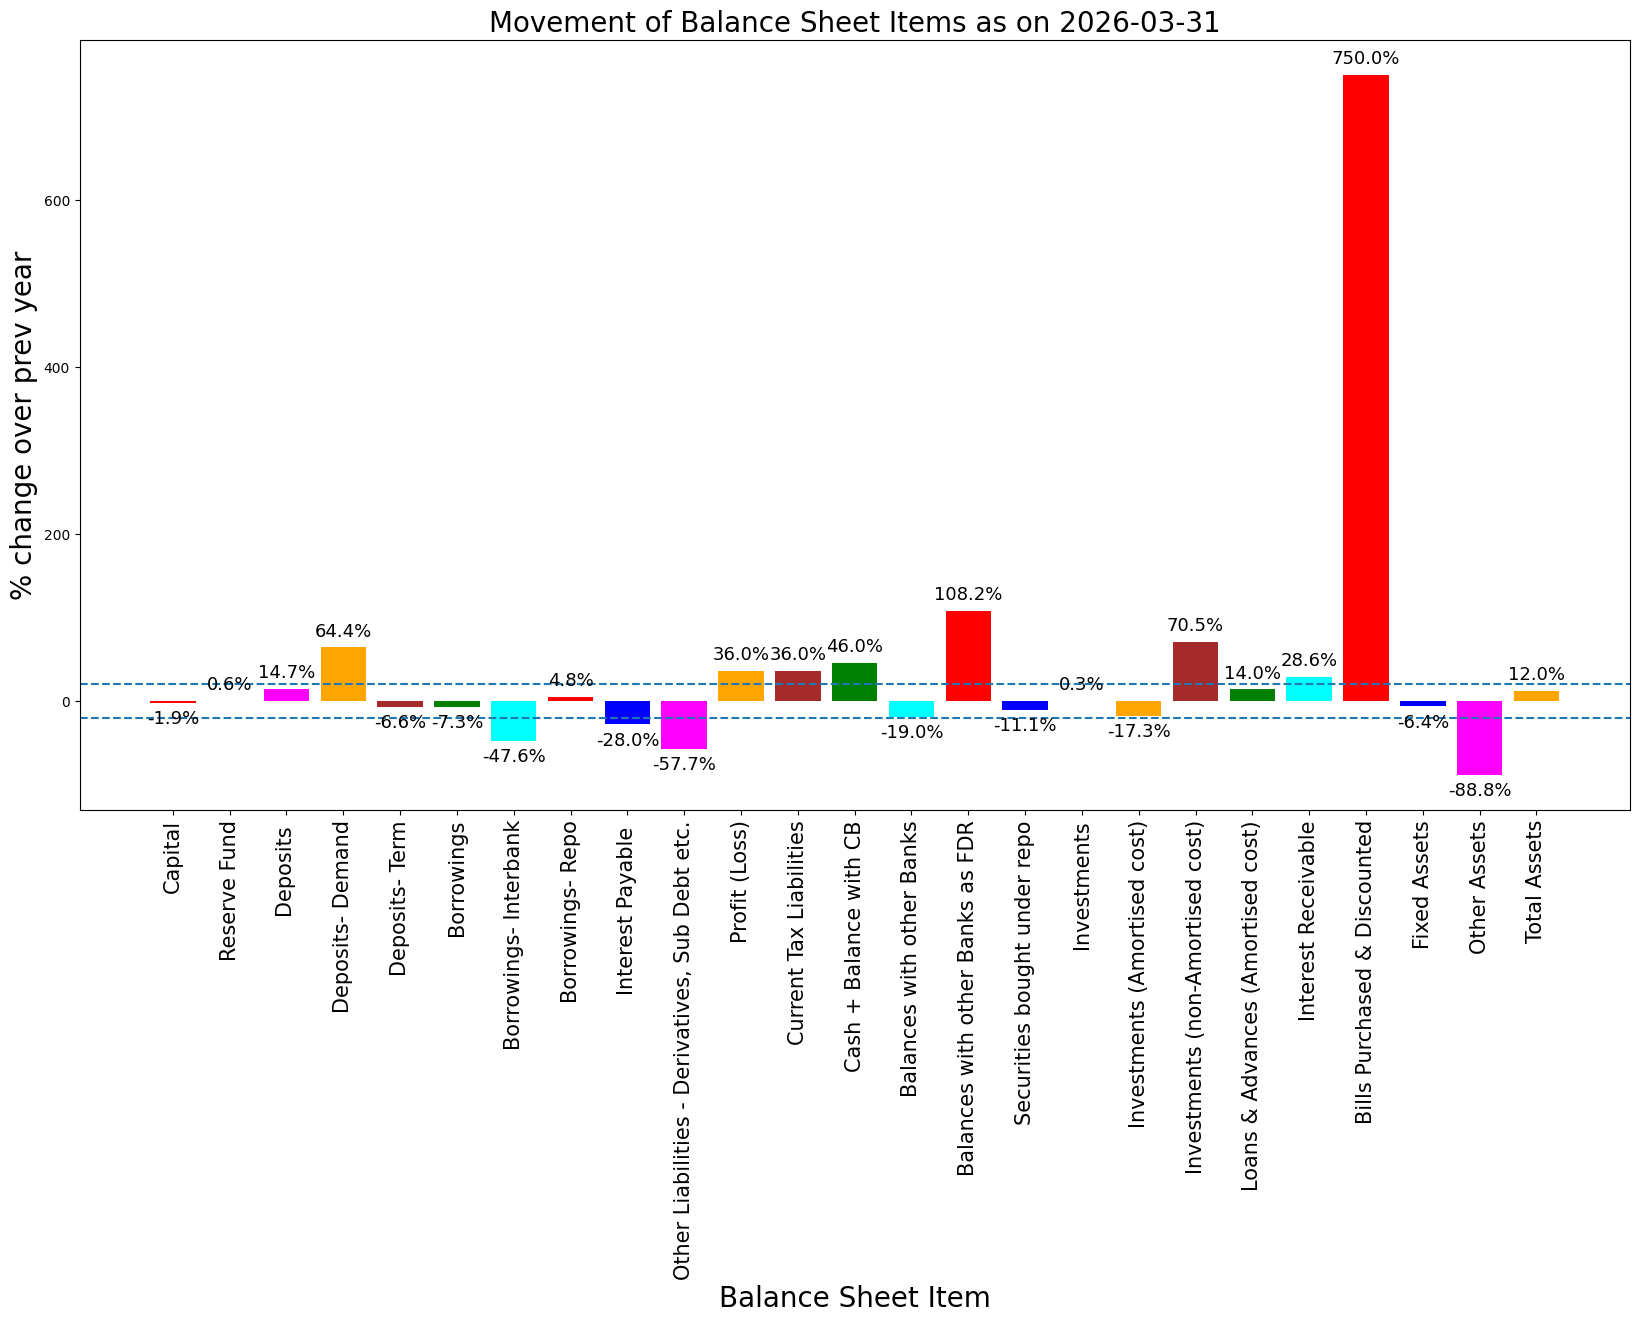

In [ ]:
# @title

# Plotting change in all BS items

fig = plt.figure(figsize=(20, 10))

c = ['red', 'blue', 'magenta', 'orange', 'brown', 'green', 'cyan']

bars = plt.bar(df2.index[np.abs(df2['% change']!=0)], df2['% change'][np.abs(df2['% change']!=0)], color=c)

# Add value labels
plt.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=13)

plt.xticks(rotation=90, fontsize=15)
plt.axhline(-20, linestyle='dashed')
plt.axhline(20, linestyle='dashed')

plt.xlabel('Balance Sheet Item', fontsize=20)
plt.ylabel('% change over prev year', fontsize=20)
plt.title(f'Movement of Balance Sheet Items as on {df2.columns[-2]}', fontsize=20)
plt.show()

In [9]:
# re-frame the data file for further processing

df2.drop(['% change'], axis = 1, inplace= True)
col_ind = [df2.columns[i] for i in range(len(df2.columns))]
df2

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Capital,14.5700,14.840000,15.64000,15.8300,15.220000,15.3800,16.1300,18.35000,20.15000,21.4300,23.3900,24.7400,24.4100,23.9400
Reserve Fund,88.2000,92.570000,95.94000,100.2500,104.740000,111.2200,118.1300,128.60000,139.95000,202.1300,216.4600,222.1700,262.2500,263.7600
Other Reserve,0.0000,0.000000,0.00000,0.0000,0.000000,0.0000,0.0000,0.00000,0.00000,0.0000,0.0000,0.0000,0.0000,0.0000
Deposits,565.1500,642.560000,746.98000,872.8800,1039.180000,1142.6100,1355.4300,1366.59000,1498.51000,1663.2600,1967.7200,2071.3800,2206.1300,2530.6600
Deposits- Demand,237.3630,218.470400,209.15440,235.6776,342.929400,354.2091,569.2806,464.64060,569.43380,415.8150,826.4424,745.6968,661.8390,1088.1838
Deposits- Term,327.7870,424.089600,537.82560,637.2024,696.250600,788.4009,786.1494,901.94940,929.07620,1247.4450,1141.2776,1325.6832,1544.2910,1442.4762
Borrowings,61.2300,119.662500,69.51250,26.8450,1.947500,1.3000,11.0800,12.06500,14.26500,14.0300,17.9900,15.6200,12.1100,11.2300
Borrowings- Interbank,9.7968,13.162875,12.51225,5.9059,0.447925,0.1560,1.8836,2.53365,2.99565,3.2269,2.8784,3.9050,2.7853,1.4599
Borrowings- Repo,51.4332,106.499625,57.00025,20.9391,1.499575,1.1440,9.1964,9.53135,11.26935,10.8031,15.1116,11.7150,9.3247,9.7701


### 1.1 Visualizing balance sheet items

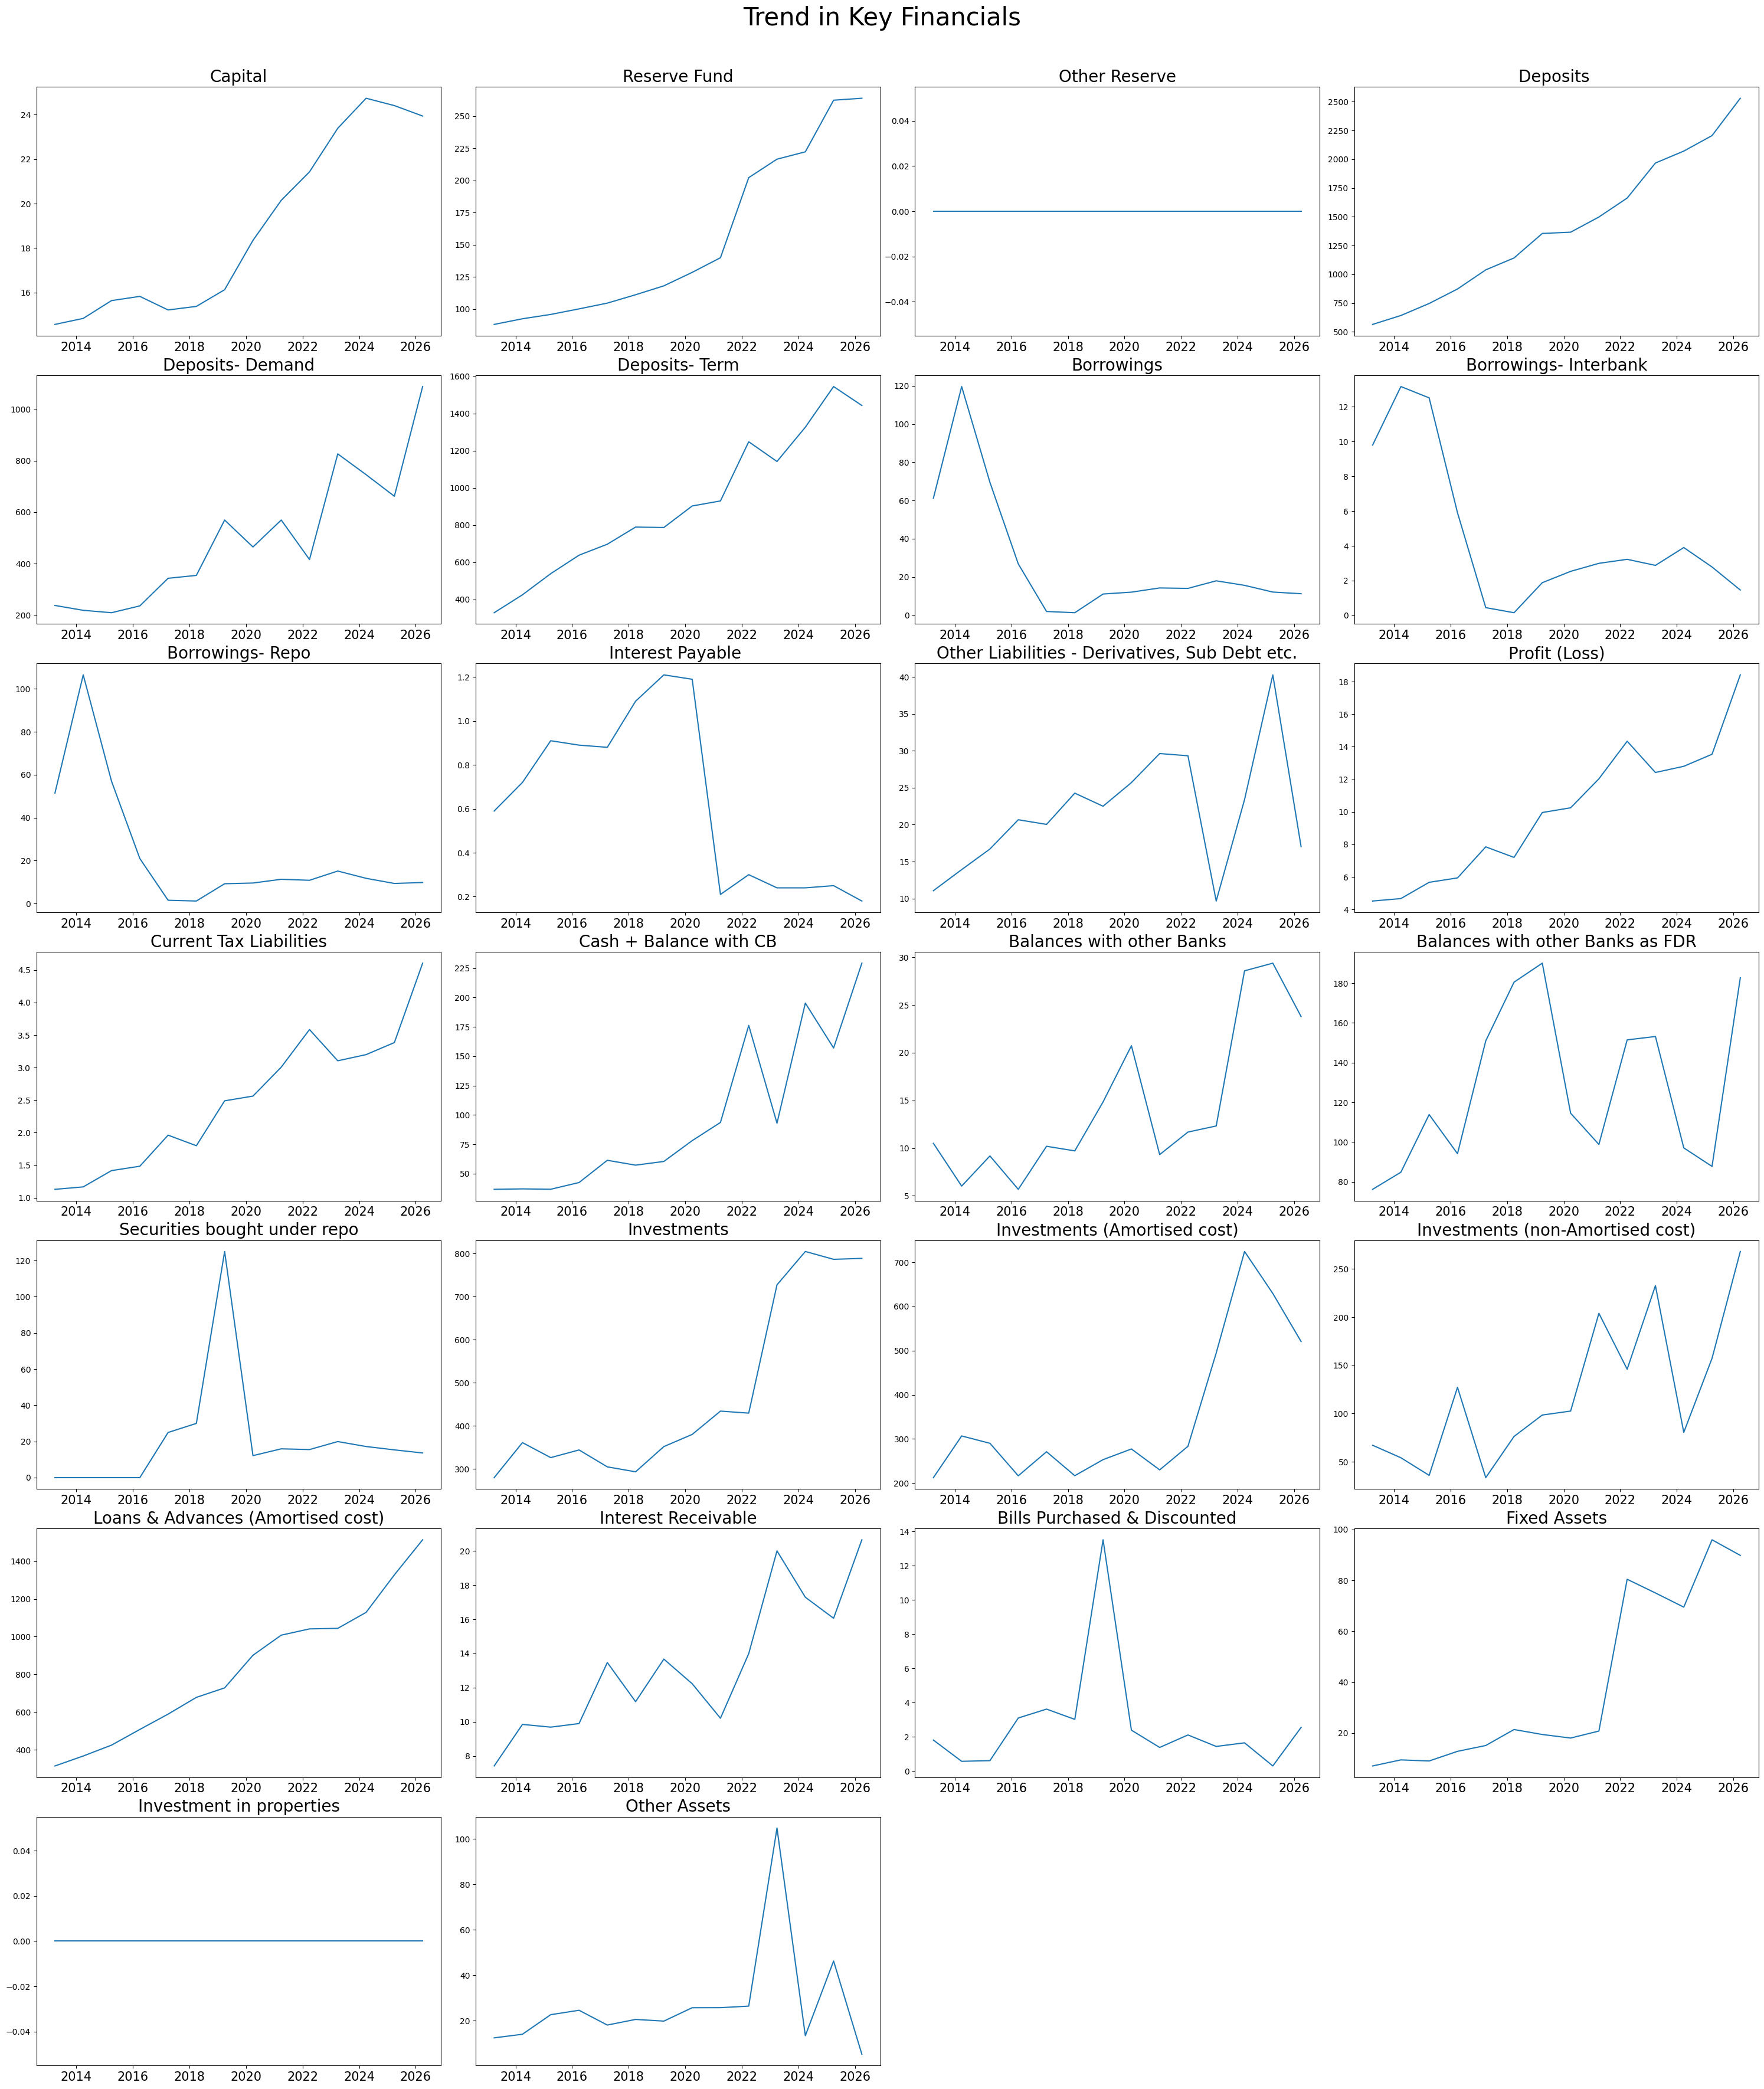

In [10]:

# plotting the timeseries plot of balance sheet items over the years

fig=plt.figure(figsize=(30,35))
#fig.tight_layout(h_pad= 0.5, w_pad= .5)

items = round(len(df2.index)/4)

for i in range(1,len(df2.index)):
    plt.subplot(items, 4, i)
    plt.plot(df2.columns,df2.iloc[i-1])
    plt.xticks(fontsize=15)
    plt.title(f'{df2.index[i-1]}', fontsize=20)

plt.suptitle('Trend in Key Financials',fontsize = 30, y = 1.01)
plt.tight_layout(h_pad=0.5, w_pad=0.5, rect=[0, 0, 1, 1])
plt.show()

### 1.2 : Analysing business model through balance sheet evolution over the years

In [11]:
# Analysing balance sheet composition over the years

selected_items_asset = ["Cash + Balance with CB", "Balances with other Banks", "Balances with other Banks as FDR",
                        "Securities bought under repo", "Investments (Amortised cost)", "Investments (non-Amortised cost)",
                       "Loans & Advances (Amortised cost)", "Interest Receivable", "Bills Purchased & Discounted",
                       "Fixed Assets", "Investment in properties", "Other Assets"]



selected_items_liab = ["Capital", "Reserve Fund", "Other Reserve", "Deposits- Demand", "Deposits- Term",
                      "Borrowings- Interbank", "Borrowings- Repo", "Interest Payable ",
                       "Other Liabilities - Derivatives, Sub Debt etc.","Profit (Loss)",
                       "Current Tax Liabilities"]



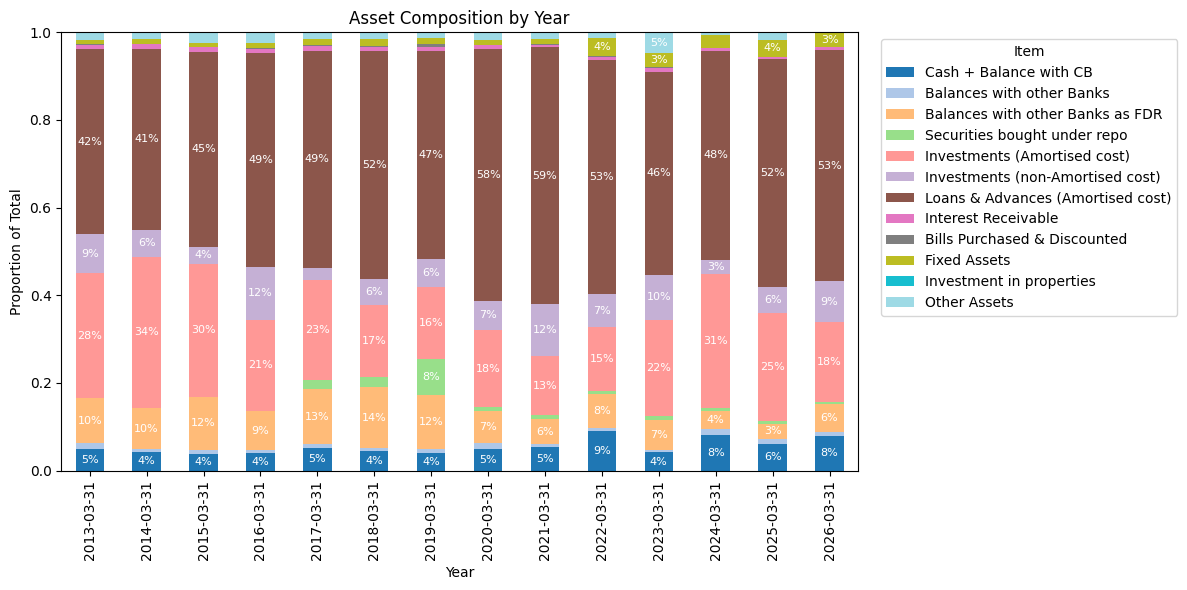

In [12]:
# Movement of Assets over the years


# Normalize each column (year) so it sums to 1

df2_subset = df2.loc[selected_items_asset]

df_norm = df2_subset.div(df2_subset.sum(axis=0), axis=1)


# Transpose so years are on x-axis, items are stacked
ax = df_norm.T.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)


# Add value labels inside each segment of every bar
for container in ax.containers:
    labels = [f"{v:.0%}" if v > 0.03 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")


ax.set_xlabel("Year")
ax.set_ylabel("Proportion of Total")
ax.set_title("Asset Composition by Year")
ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

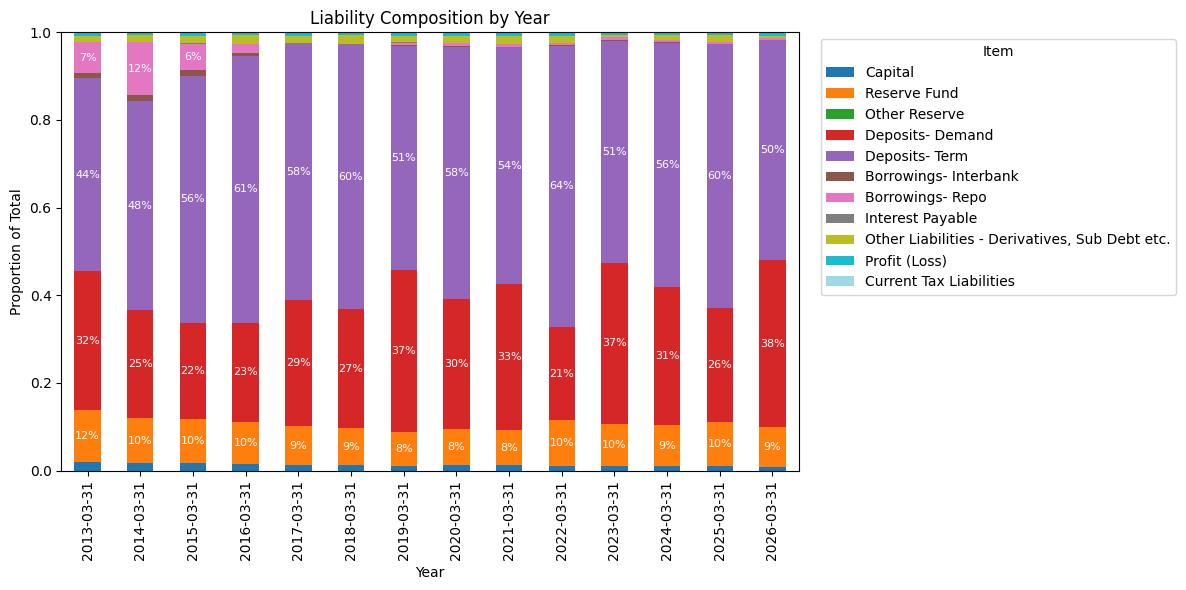

In [13]:
# Movement of liabilities over the years


# Normalize each column (year) so it sums to 1

df2_subset = df2.loc[selected_items_liab]

df_norm = df2_subset.div(df2_subset.sum(axis=0), axis=1)


# Transpose so years are on x-axis, items are stacked
ax = df_norm.T.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)


# Add value labels inside each segment of every bar
for container in ax.containers:
    labels = [f"{v:.0%}" if v > 0.03 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")



ax.set_xlabel("Year")
ax.set_ylabel("Proportion of Total")
ax.set_title("Liability Composition by Year")
ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 1.3 Balance sheet ratios for labeling type of business model

i.	**Retail-funded**: it is characterised by a high share of loans on the balance sheet and high reliance on stable funding sources including deposits.

ii.	**Wholesale-funded**:high share of loans on the balance sheet and high reliance on wholesale funding sources including deposits

iii. **Trading bank**: More capital markets-oriented. Banks in this category hold half of their assets in the form of tradable securities and are predominately funded in wholesale markets. In fact, the average bank in this group is most active in the interbank market.



In [14]:
# First compute key ratios

bma_ratios = pd.DataFrame(index=df2.columns)
bma_ratios['loan_share'] = np.round(list(100*df2.loc["Loans & Advances (Amortised cost)"]/df2.loc["Total Assets"]),2)
bma_ratios['intbk_borrowing'] = np.round(list(100*df2.loc["Borrowings- Interbank"]/df2.loc["Total Assets"]),2)
bma_ratios['wholesale_debt'] = np.round(list(100*df2.loc["Deposits- Term"]/df2.loc["Total Assets"]),2)




In [15]:
bma_ratios

,loan_share,intbk_borrowing,wholesale_debt
2013-03-31,42.17,1.31,43.91
2014-03-31,41.28,1.48,47.65
2015-03-31,44.60,1.31,56.45
2016-03-31,48.64,0.57,60.99
2017-03-31,49.46,0.04,58.42
2018-03-31,51.97,0.01,60.42
2019-03-31,47.40,0.12,51.15
2020-03-31,57.59,0.16,57.62
2021-03-31,58.67,0.17,54.09
2022-03-31,53.44,0.17,64.02


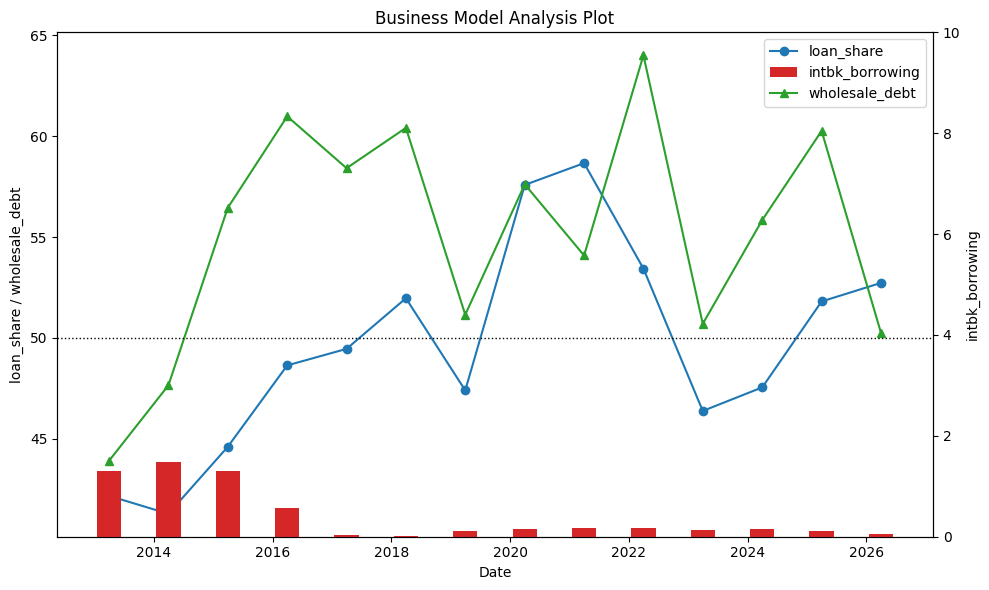

In [16]:
# Plotting movement of key ratios over the years

bma_ratios.index = pd.to_datetime(bma_ratios.index)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bar plot on secondary axis
l2 = ax2.bar(
    bma_ratios.index, bma_ratios["intbk_borrowing"],
    width=150, color="tab:red", label="intbk_borrowing", zorder=1
)
ax2.set_ylabel("intbk_borrowing")
ax2.set_ylim(0, 10)

# Line plots on primary axis
l1, = ax1.plot(
    bma_ratios.index, bma_ratios["loan_share"],
    color="tab:blue", marker="o", label="loan_share", zorder=2
)
l3, = ax1.plot(
    bma_ratios.index, bma_ratios["wholesale_debt"],
    color="tab:green", marker="^", label="wholesale_debt", zorder=2
)
ax1.set_ylabel("loan_share / wholesale_debt")
ax1.set_xlabel("Date")


ax1.axhline(y=50, color="black", linestyle=":", linewidth=1)

# Combined legend
handles = [l1, l2, l3]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper right")

plt.title("Business Model Analysis Plot")
fig.tight_layout()
plt.show()

# 2. Analysis of Profit & Loss

In [17]:
# Reading the p&L data

df7=pd.read_excel(f'{filename}',sheet_name='P&L',index_col=0, parse_dates=True)
df7.fillna(0)
df7['% change'] = np.round((np.divide(np.array(df7.iloc[:,-1:]), np.array(df7.iloc[:,-2:-1]))-1)*100,2)


In [ ]:
df7

,2013-03-31 00:00:00,2014-03-31 00:00:00,2015-03-31 00:00:00,2016-03-31 00:00:00,2017-03-31 00:00:00,2018-03-31 00:00:00,2019-03-31 00:00:00,2020-03-31 00:00:00,2021-03-31 00:00:00,2022-03-31 00:00:00,2023-03-31 00:00:00,2024-03-31 00:00:00,2025-03-31 00:00:00,2026-03-31 00:00:00,% change
Income,,,,,,,,,,,,,,,
Interest Income,54.23,67.48,77.76,88.37,100.76,108.14,115.65,120.20,128.60,140.03,139.94,144.11,159.86,193.78,21.22
Other Income,6.31,8.82,13.83,13.02,15.37,12.24,12.55,19.00,16.43,22.13,31.44,27.80,28.54,20.78,-27.19
Total Income,60.54,76.30,91.59,101.39,116.13,120.38,128.20,139.20,145.03,162.16,171.38,171.91,188.40,214.56,13.89
Interest Exp,31.58,45.40,54.19,62.62,71.07,76.32,82.74,82.44,86.51,101.85,108.52,104.68,109.37,144.26,31.90
Operating Exp,14.58,15.81,18.71,21.19,22.33,23.52,24.08,27.14,28.76,29.84,34.53,33.90,42.35,39.44,-6.87
Other Operating Exp,2.42,2.53,2.69,2.79,3.38,5.02,5.64,7.40,5.64,6.41,6.65,12.67,7.35,4.91,-33.20
Total operating Exp,17.00,18.34,21.40,23.98,25.71,28.54,29.72,34.54,34.40,36.25,41.18,46.57,49.70,44.35,-10.76
Profit before provisions & tax,11.96,12.56,16.00,14.79,19.35,15.52,15.74,22.22,24.12,24.06,21.68,20.66,29.33,25.95,-11.52
Provision (Loans & contingencies),7.44,7.89,10.33,8.85,11.50,8.32,5.78,11.97,12.09,9.72,9.26,7.86,15.79,7.53,-52.31


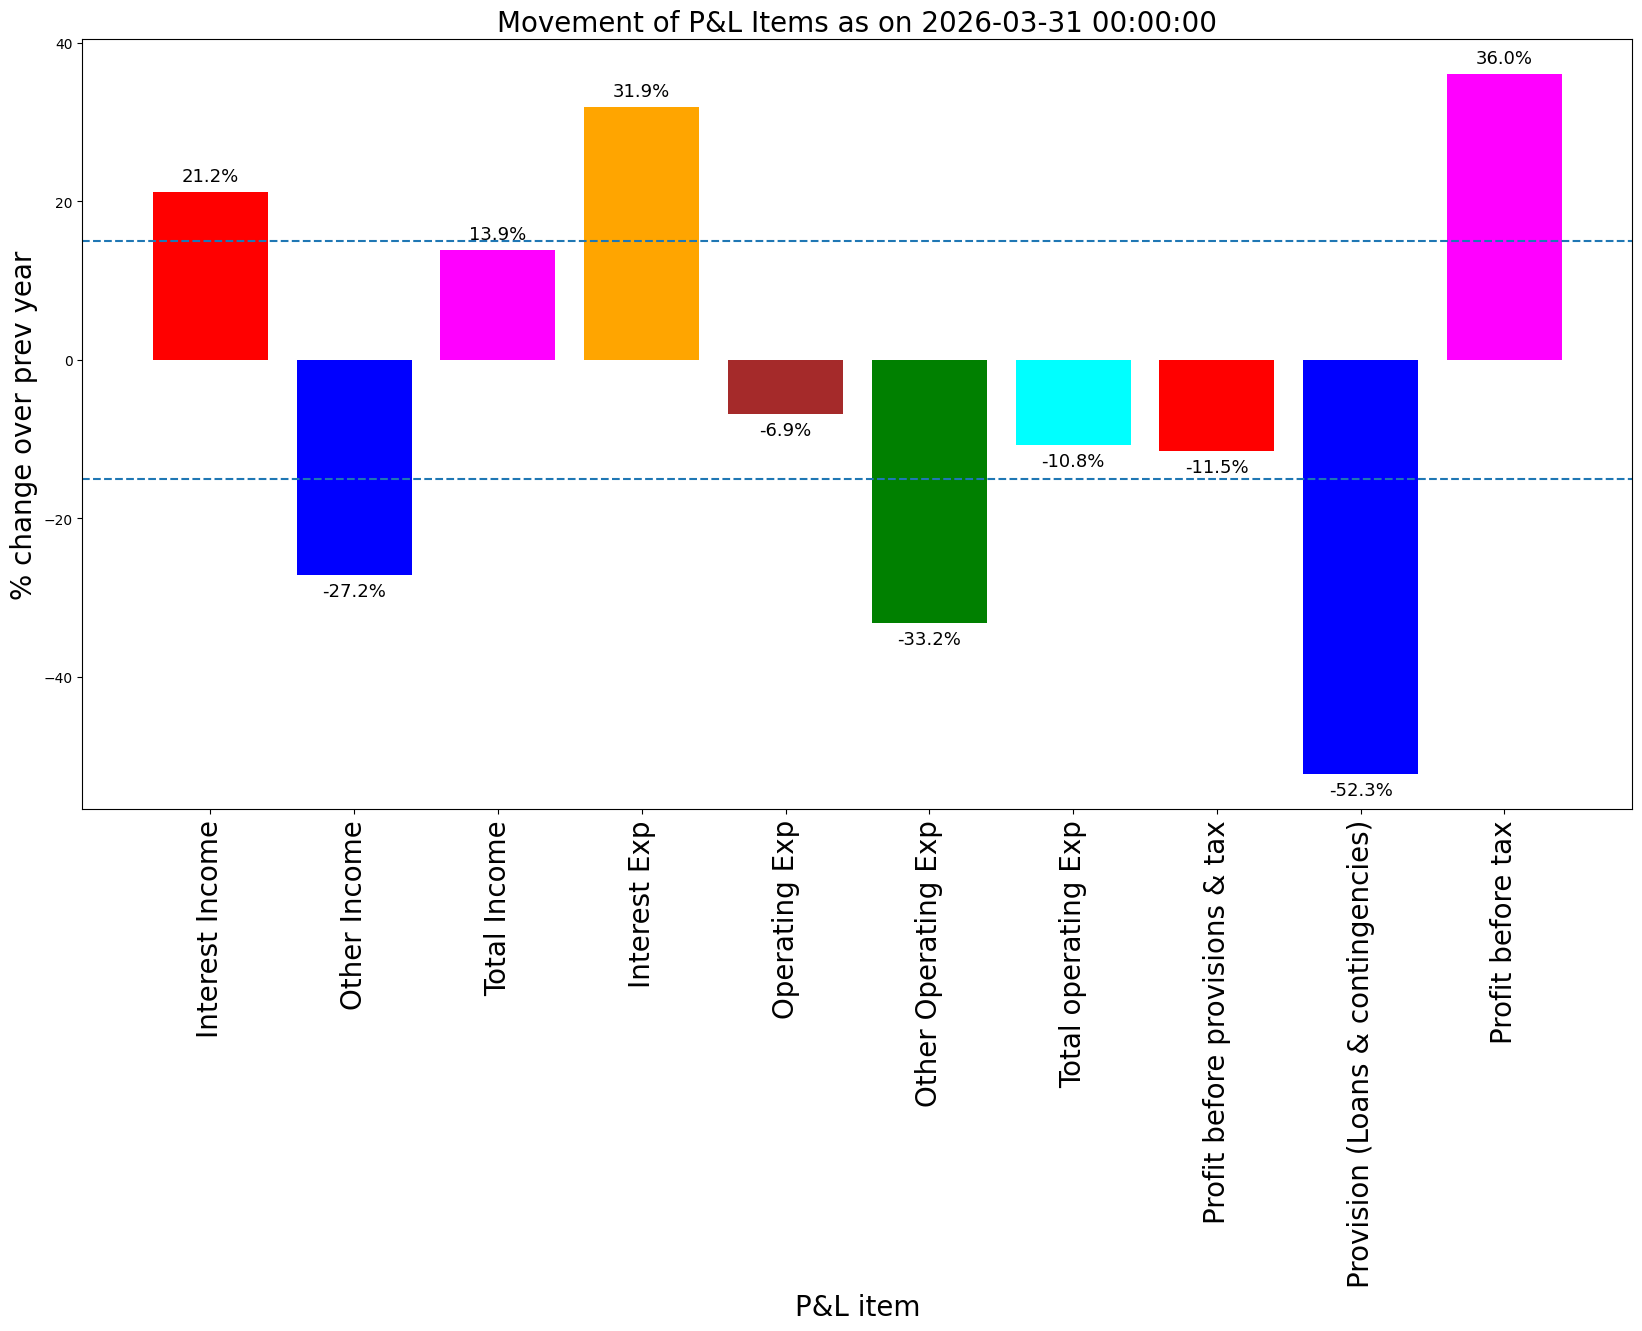

In [ ]:
# @title
# plottng YoY change in P&L Items

fig=plt.figure(figsize=(20,10))

c = ['red', 'blue', 'magenta', 'orange', 'brown', 'green', 'cyan']
bars = plt.bar(df7.index[np.abs(df7['% change']!=0)], df7['% change'][np.abs(df7['% change']!=0)], color = c)

# Add value labels
plt.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=13)

plt.xticks(rotation = 90, fontsize = 20)
plt.axhline(-15, linestyle = 'dashed')
plt.axhline(15, linestyle = 'dashed')
plt.title(f'Movement of P&L Items as on {df7.columns[-2]}', fontsize = 20)
plt.xlabel('P&L item', fontsize = 20)
plt.ylabel('% change over prev year', fontsize = 20)

plt.show()

In [18]:
# Analysing P&L composition over the years

selected_items_income = ["Interest Income", "Other Income"]
selected_items_exp = ["Interest Exp", "Operating Exp", "Other Operating Exp", "Provision (Loans & contingencies)"]


In [19]:
df7.drop(['% change'], axis =1, inplace = True)

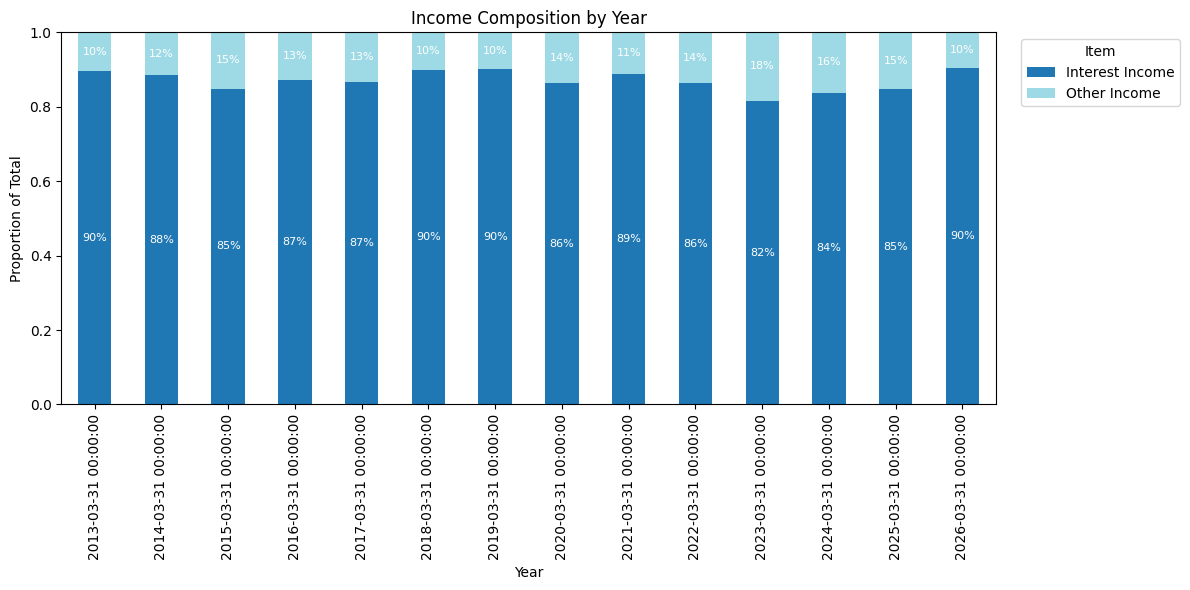

In [20]:
# Movement of Income over the years


# Normalize each column (year) so it sums to 1

df7_subset = df7.loc[selected_items_income]

df_norm = df7_subset.div(df7_subset.sum(axis=0), axis=1)


# Transpose so years are on x-axis, items are stacked
ax = df_norm.T.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)


# Add value labels inside each segment of every bar
for container in ax.containers:
    labels = [f"{v:.0%}" if v > 0.03 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")


ax.set_xlabel("Year")
ax.set_ylabel("Proportion of Total")
ax.set_title("Income Composition by Year")
ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

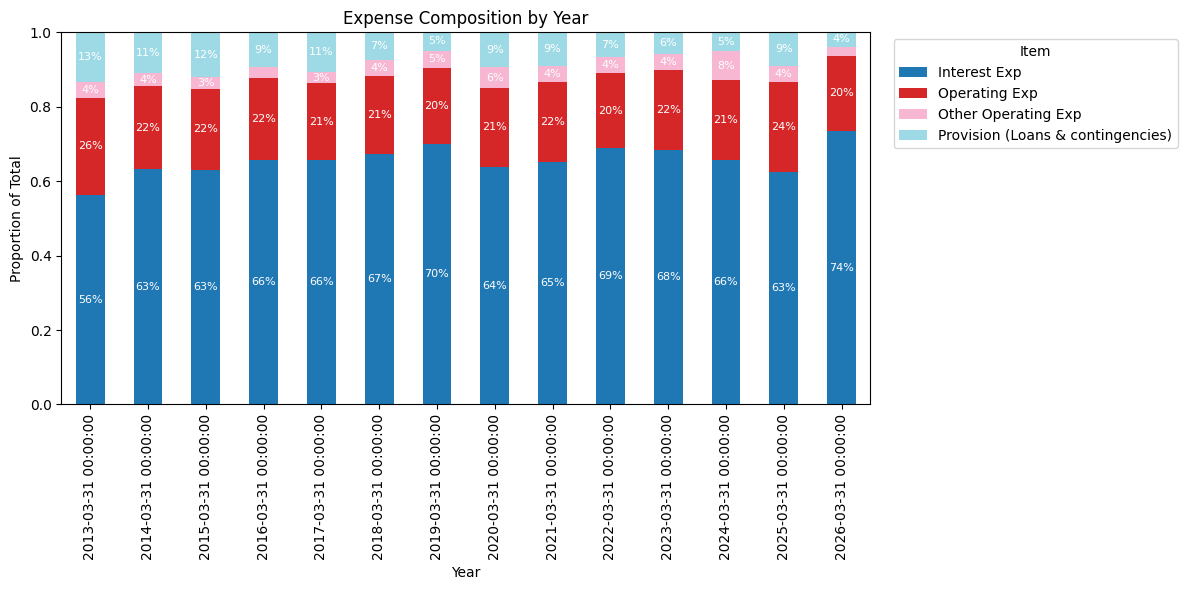

In [21]:
# Movement of Income over the years


# Normalize each column (year) so it sums to 1

df7_subset = df7.loc[selected_items_exp]

df_norm = df7_subset.div(df7_subset.sum(axis=0), axis=1)


# Transpose so years are on x-axis, items are stacked
ax = df_norm.T.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20"
)


# Add value labels inside each segment of every bar
for container in ax.containers:
    labels = [f"{v:.0%}" if v > 0.03 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")


ax.set_xlabel("Year")
ax.set_ylabel("Proportion of Total")
ax.set_title("Expense Composition by Year")
ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 2.1 Earnings Analysis

Here we disect the components of Return on Capital Employed (ROCE) into various sub-components to gain insight into sources and quality of earnings. A typical company's P&L can be viewed as consisting of following items:

Sales

-COGS
________________
**Gross Profit**

-SG&A
___________________
**Operating Profit**

-Depreciation & Provisions

__________________________
**EBIT**

-Interest paid
____________________________
**EBT**

-Taxes
_________________________
**Net Income**




However, in case of banks, Interest paid is treated as COGS since that is the cost paid by banks to generate sales i.e., earn income on its assets.

and ROCE may be expressed as:


$$ROCE=\frac{PBT} {Average\ Capital}$$



For a bank, we make the following adjustments:

**Total Income** = Interest Income + Other Income

**PBT** = Interest Income + Other Income - Interest Expense - Total Operating Exp - Provisions

**Average Capital** = (Opening Capital + Closing Capital)/2

**Average Total Assets** = (Opening Total Assets + Closing Total Assets)/2

And, we break the ROCE in sub-components to analyze the bank's income drivers:



$$ROCE= \frac {PBT} {Tot Income} \ X \  \frac {Tot Income} {Average\ Total\ Assets}  \ X \  \frac {Average\ Total\ Assets} {Average \ Capital}$$

In [26]:
# Creating P&L variables for analysis


sales= df7.loc['Total Income']

PBT= df7.loc['Profit before tax']

total_assets = df2.loc['Total Assets']

capital= df2.loc['Capital']+ df2.loc['Reserve Fund'] + df2.loc['Other Reserve']


# Calculating average total asset as sum of opening and closing total asset

avg_total_assets={}
for i in range(1,len(df2.columns)):
    avg_total_assets[df2.columns[i]]=round((total_assets[i-1]+total_assets[i])/2,2)


avg_total_assets=list(avg_total_assets.values())
avg_total_assets.insert(0,0)

# Calculating average total capital as sum of opening and closing total capital

avg_total_capital={}
for j in range(1,len(df2.columns)):
    avg_total_capital[df2.columns[j]]=round((capital[j-1]+capital[j])/2,2)


avg_total_capital=list(avg_total_capital.values())
avg_total_capital.insert(0,0)

# Calculating the Ratios

PBT_to_Sales = PBT/sales

sales_to_avg_total_asset= sales/avg_total_assets

roce = 100 * PBT/avg_total_assets

avg_assets_to_capital={}
for i in range(1,len(avg_total_assets)):
    avg_assets_to_capital[df2.columns[i]]= avg_total_assets[i]/avg_total_capital[i]

avg_assets_to_capital=list(avg_assets_to_capital.values())
avg_assets_to_capital.insert(0,0)

In [27]:
# @title
data=np.array([sales,PBT,avg_total_assets,avg_total_capital])
A=pd.DataFrame(data, columns=col_ind, index=['Sales','PBT','Avg_Tot_Assets','Avg_Tot_Capital'])

In [28]:
# @title
A

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
Sales,60.54,76.30,91.59,101.39,116.13,120.38,128.20,139.20,145.03,162.16,171.38,171.91,188.40,214.56
PBT,4.52,4.67,5.67,5.94,7.85,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42
Avg_Tot_Assets,0.00,818.28,921.43,998.77,1118.29,1248.34,1420.89,1551.11,1641.52,1833.07,2099.69,2312.26,2467.94,2716.08
Avg_Tot_Capital,0.00,105.09,109.50,113.83,118.02,123.28,130.43,140.60,153.52,191.83,231.70,243.38,266.79,287.18


In [29]:
# @title
ratio_data=np.array([PBT_to_Sales,sales_to_avg_total_asset,avg_assets_to_capital,roce])

In [30]:
# @title
B=pd.DataFrame(ratio_data, columns=col_ind, index=['PBT/Income','Tot Income/Avg Assets',
                                                   'Avg Assets/Capital','ROCE'])

In [31]:
# @title
C=B.iloc[:,1:len(B.columns)]

In [33]:
# @title
C

,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
PBT/Income,0.061206,0.061906,0.058586,0.067597,0.059811,0.077691,0.073635,0.082948,0.088431,0.072471,0.074458,0.071868,0.085850
Tot Income/Avg Assets,0.093244,0.099400,0.101515,0.103846,0.096432,0.090225,0.089742,0.088351,0.088464,0.081622,0.074347,0.076339,0.078996
Avg Assets/Capital,7.786469,8.414886,8.774225,9.475428,10.126055,10.893889,11.032077,10.692548,9.555700,9.062106,9.500616,9.250497,9.457762
ROCE,0.570709,0.615348,0.594732,0.701965,0.576766,0.700969,0.660817,0.732857,0.782294,0.591516,0.553571,0.548636,0.678183


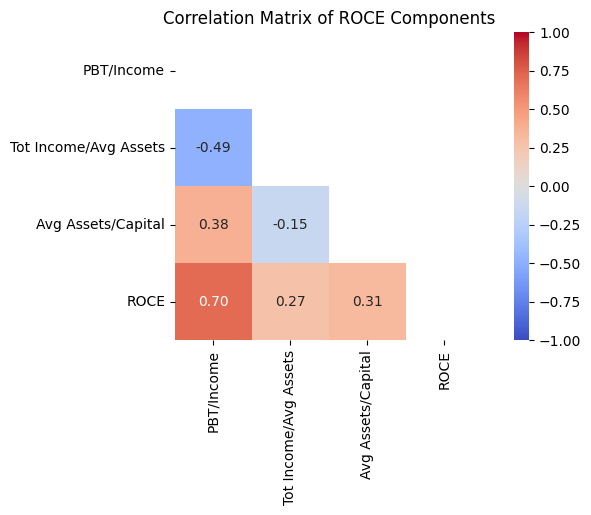

In [ ]:
corr = C.T.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hides upper triangle

plt.figure(figsize=(8,4))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of ROCE Components')
plt.show()

### 2.1.1 Return on Capital Employed (ROCE) Analysis

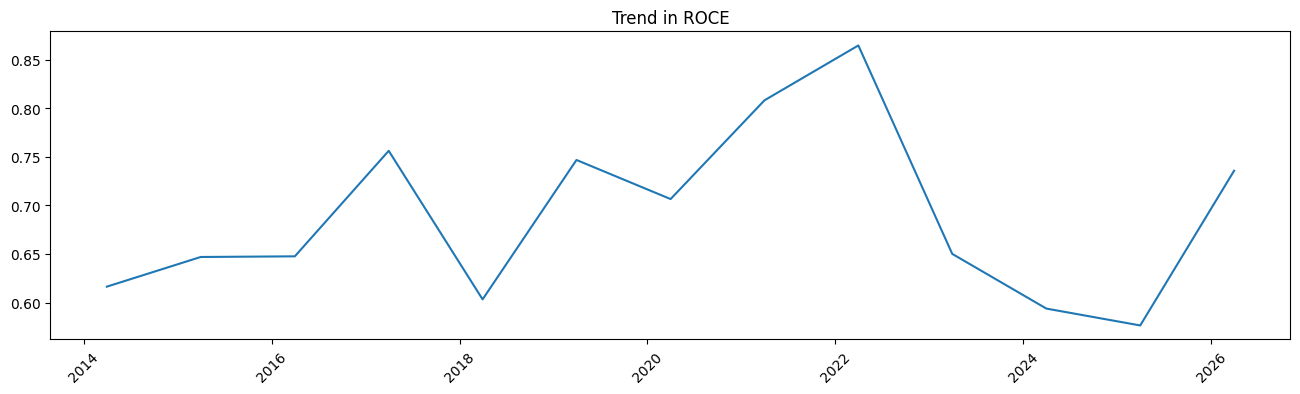

In [ ]:
fig=plt.figure(figsize=(16,4))
plt.plot(C.columns,C.iloc[3])
plt.title('Trend in ROCE')
plt.xticks(rotation=45)
plt.show()

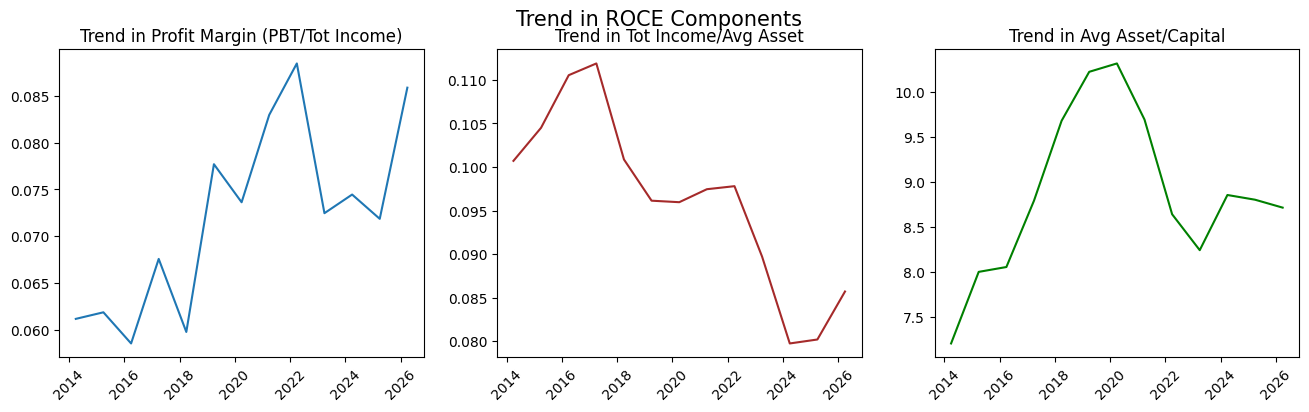

In [ ]:
# Plotting ROCE



fig=plt.figure(figsize=(16,4))
fig.suptitle('Trend in ROCE Components', fontsize=15)


plt.subplot(1,3,1)
plt.plot(C.columns,C.iloc[0])
plt.title('Trend in Profit Margin (PBT/Tot Income)')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
plt.plot(C.columns,C.iloc[1], color = 'brown')
plt.title('Trend in Tot Income/Avg Asset')
plt.xticks(rotation=45)

plt.subplot(1,3,3)
plt.plot(C.columns,C.iloc[2], color = 'green')
plt.title('Trend in Avg Asset/Capital')
plt.xticks(rotation=45)

plt.show()

### 2.1.2 Components of Profit Margin (PBT/Tot Income)

We further break PBT into sub-components to analyze the trend of the period:



$$ \frac {PBT} {Tot Income} = \frac {Interest\ Income} {Tot Income} \ + \  \frac {Other\ Receipts} {Tot Income}  \ - \  \frac {Interest Paid} {Tot Income} - \  \frac {Operating \ Expense} {Tot Income} - \  \frac {Other\ Operating\ Expense} {Tot Income} - \  \frac {Provision} {Tot Income} $$

In [ ]:
# @title
df7

,2013-03-31 00:00:00,2014-03-31 00:00:00,2015-03-31 00:00:00,2016-03-31 00:00:00,2017-03-31 00:00:00,2018-03-31 00:00:00,2019-03-31 00:00:00,2020-03-31 00:00:00,2021-03-31 00:00:00,2022-03-31 00:00:00,2023-03-31 00:00:00,2024-03-31 00:00:00,2025-03-31 00:00:00,2026-03-31 00:00:00
Income,,,,,,,,,,,,,,
Interest Income,54.23,67.48,77.76,88.37,100.76,108.14,115.65,120.20,128.60,140.03,139.94,144.11,159.86,193.78
Other Income,6.31,8.82,13.83,13.02,15.37,12.24,12.55,19.00,16.43,22.13,31.44,27.80,28.54,20.78
Total Income,60.54,76.30,91.59,101.39,116.13,120.38,128.20,139.20,145.03,162.16,171.38,171.91,188.40,214.56
Interest Exp,31.58,45.40,54.19,62.62,71.07,76.32,82.74,82.44,86.51,101.85,108.52,104.68,109.37,144.26
Operating Exp,14.58,15.81,18.71,21.19,22.33,23.52,24.08,27.14,28.76,29.84,34.53,33.90,42.35,39.44
Other Operating Exp,2.42,2.53,2.69,2.79,3.38,5.02,5.64,7.40,5.64,6.41,6.65,12.67,7.35,4.91
Total operating Exp,17.00,18.34,21.40,23.98,25.71,28.54,29.72,34.54,34.40,36.25,41.18,46.57,49.70,44.35
Profit before provisions & tax,11.96,12.56,16.00,14.79,19.35,15.52,15.74,22.22,24.12,24.06,21.68,20.66,29.33,25.95
Provision (Loans & contingencies),7.44,7.89,10.33,8.85,11.50,8.32,5.78,11.97,12.09,9.72,9.26,7.86,15.79,7.53


In [ ]:
# @title
# Plotting the normalised P&L items

Int_Income = df7.loc['Interest Income']
Int_Income_to_sales=Int_Income/sales
#print(Int_Income_to_sales)



Oth_receipts = df7.loc['Other Income']
Oth_receipts_to_sales = Oth_receipts/sales
#print(Oth_receipts_to_sales)


Int_paid = df7.loc['Interest Exp']
Int_paid_to_sales = Int_paid/sales
#print(Int_paid_to_sales)



Op_exp=df7.loc['Operating Exp']
Op_exp_to_sales = Op_exp/sales
#print(Op_exp_to_sales)


Oth_op_exp=df7.loc['Other Operating Exp']
Oth_op_exp_to_sales=Oth_op_exp/sales
#print(Oth_op_exp_to_sales)


provision=df7.loc['Provision (Loans & contingencies)']
provision_to_sales=provision/sales
#print(provision_to_sales)



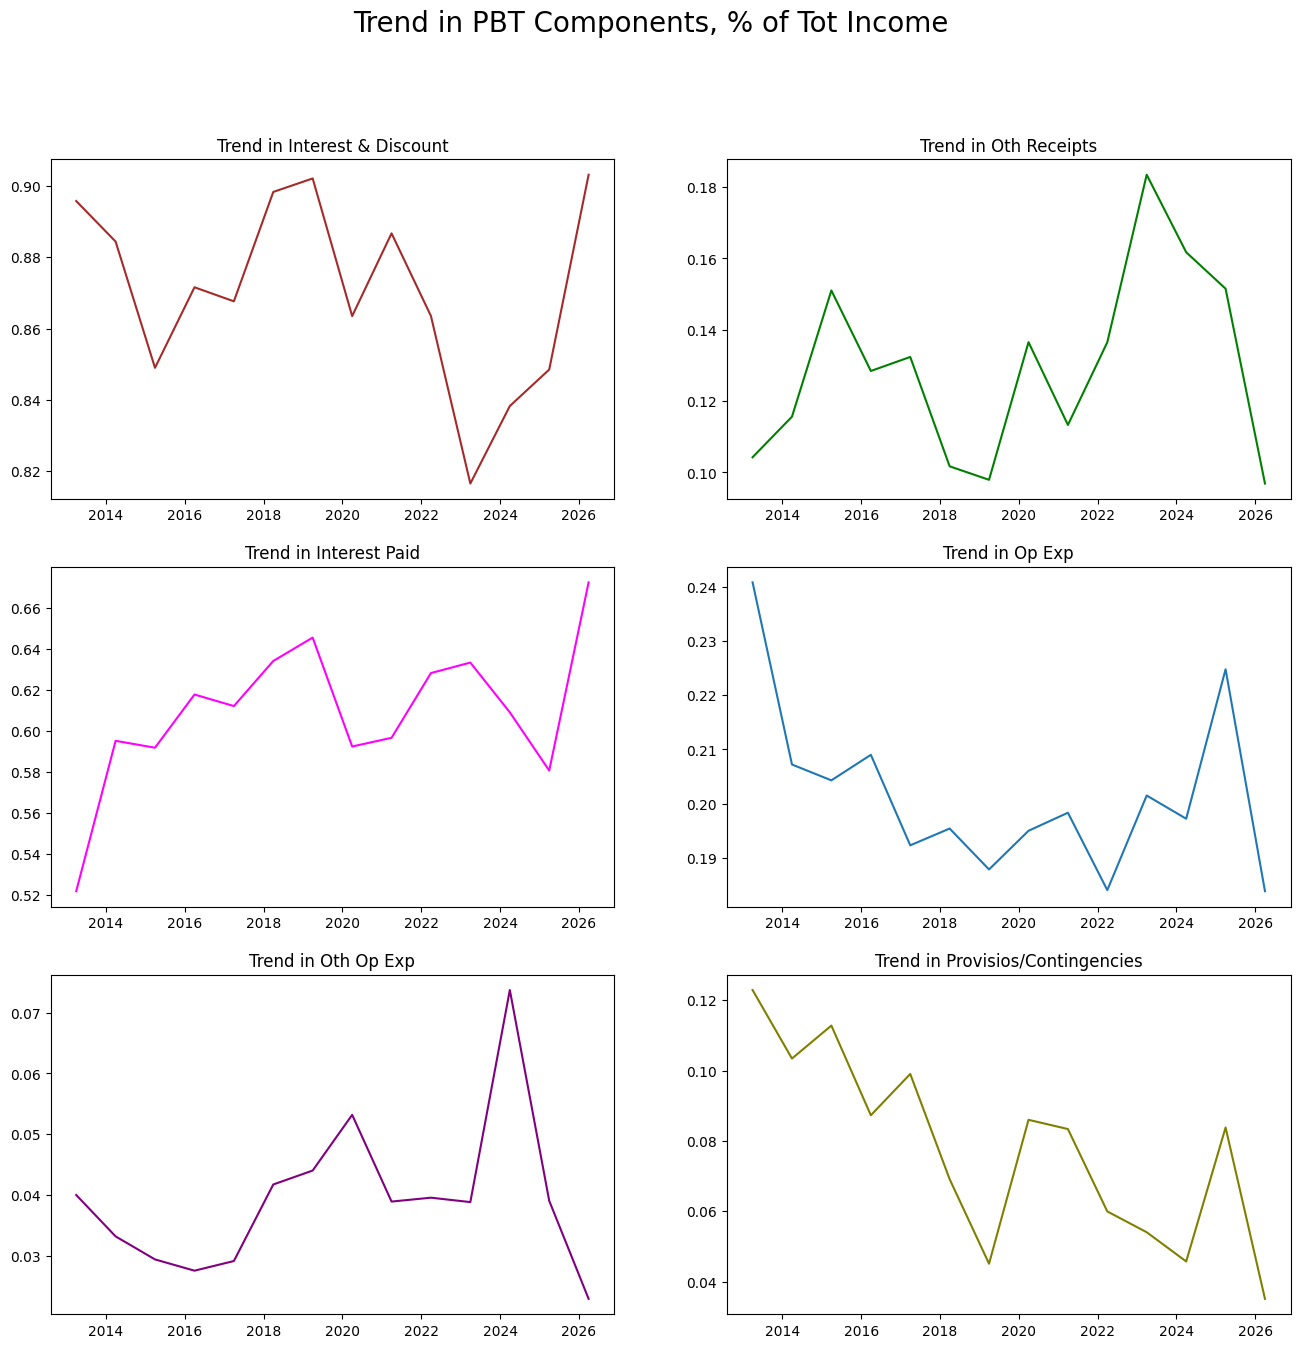

In [ ]:
#Plotting trends in P&L Accounts

fig=plt.figure(figsize=(16,15))
fig.suptitle('Trend in PBT Components, % of Tot Income', fontsize=20)
fig.tight_layout(h_pad=10)

plt.subplot(3,2,1)
#plt.plot(data2.columns,data2.iloc[0], color = 'brown')
plt.plot(Int_Income_to_sales, color = 'brown')
plt.title('Trend in Interest & Discount')

plt.subplot(3,2,2)
plt.plot(Oth_receipts_to_sales, color = 'green')
plt.title('Trend in Oth Receipts')

plt.subplot(3,2,3)
plt.plot(Int_paid_to_sales, color = 'magenta')
plt.title('Trend in Interest Paid')

plt.subplot(3,2,4)
plt.plot(Op_exp_to_sales)
plt.title('Trend in Op Exp')

plt.subplot(3,2,5)
plt.plot(Oth_op_exp_to_sales, color = 'purple')
plt.title('Trend in Oth Op Exp')

plt.subplot(3,2,6)
plt.plot(provision_to_sales, color = 'olive')
plt.title('Trend in Provisios/Contingencies')

plt.show()

# 3. Efficiency of operation

In [ ]:
cost_to_income = df7.loc["Total operating Exp"]/df7.loc["Total Income"]

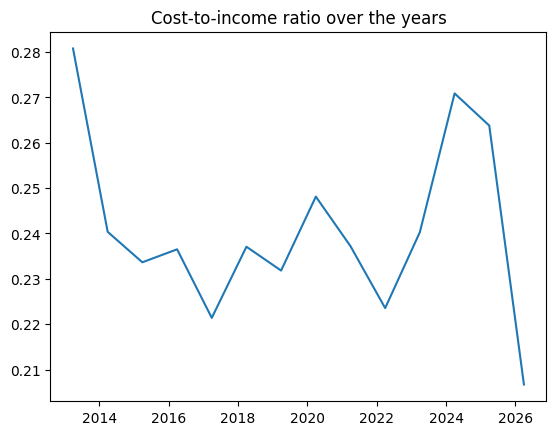

In [ ]:
plt.plot(cost_to_income)
plt.title("Cost-to-income ratio over the years")
plt.show()